### Load Dataset

In [19]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the .h5ad file
adata = sc.read_h5ad('GSE211785_7_13_23_slide0_annotated_iPTsubclusters.h5ad')

# Basic inspection
print(adata)  # Shows shape: cells x genes
print(adata.obs.head())  # Cell metadata (e.g., clusters, sample info)
print(adata.var.head())  # Gene metadata
print(adata.uns.keys())  # Unstructured data (e.g., colors, dendrograms)

# Check for key annotations (e.g., disease vs. control)
if 'condition' in adata.obs.columns:  # Assuming columns like 'condition' or 'disease_status'
    print(adata.obs['condition'].value_counts())  # e.g., CKD vs. healthy

AnnData object with n_obs × n_vars = 558601 × 1001
    obs: 'nn_33131227.a09b.4d87.addf.d7bb907597e5_1_cluster_cluster_e1ad5c7b.3174.4ee9.bfbc.d6efb6833675_1', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_clusters', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_posterior_probability', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.B', 'Max.B', 'Mean.CK8.18', 'Max.CK8.18', 'Mean.Membrane', 'Max.Membrane', 'Mean.R', 'Max.R', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'slide_ID_numeric', 'Run_Tissue_name', 'Panel', 'cell_ID', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell'

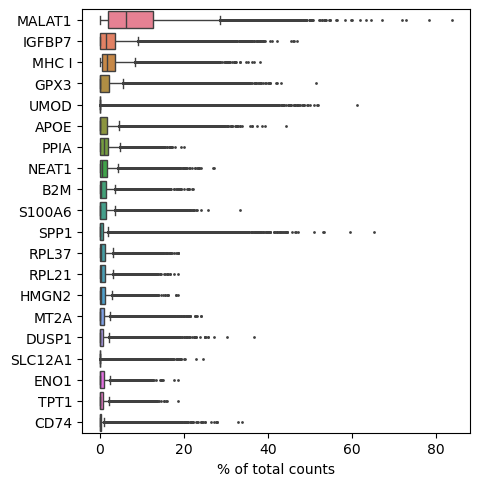

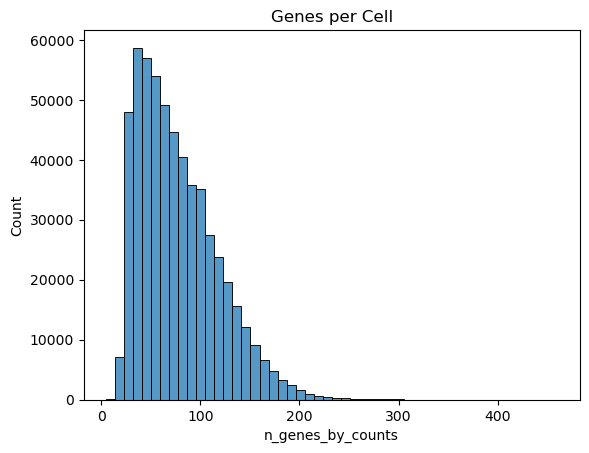

/home/nazmulhasan77/miniconda3/envs/rnaseq/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/nazmulhasan77/miniconda3/envs/rnaseq/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [4]:
# QC metrics
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

# Plot QC (visualize to decide filters)
sc.pl.highest_expr_genes(adata, n_top=20, show=True)  # Top expressed genes
plt.figure()
sns.histplot(adata.obs['n_genes_by_counts'], bins=50)
plt.title('Genes per Cell')
plt.show()

# Filter cells/genes (adjust thresholds based on your plots)
sc.pp.filter_cells(adata, min_genes=200)  # Cells with <200 genes
sc.pp.filter_genes(adata, min_cells=3)   # Genes in <3 cells

# Mitochondrial/ribosomal filtering (if not already done)
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # Human mito genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts < 5000, :]  # Example: remove high-gene outliers
adata = adata[adata.obs.pct_counts_mt < 20, :]        # <20% mito

# Normalization and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]

# Regress out effects (e.g., cell cycle or mito)
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# Scale data
sc.pp.scale(adata, max_value=10)

In [9]:
print("All columns in adata.obs:")
print(adata.obs.columns.tolist())

print("\n--- Checking common grouping columns ---")
for col in adata.obs.columns:
    if adata.obs[col].nunique() < 20:   # only show columns that are useful for grouping
        print(f"{col} → {adata.obs[col].value_counts().to_dict()}")

All columns in adata.obs:
['nn_33131227.a09b.4d87.addf.d7bb907597e5_1_cluster_cluster_e1ad5c7b.3174.4ee9.bfbc.d6efb6833675_1', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_clusters', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_posterior_probability', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.B', 'Max.B', 'Mean.CK8.18', 'Max.CK8.18', 'Mean.Membrane', 'Max.Membrane', 'Mean.R', 'Max.R', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'slide_ID_numeric', 'Run_Tissue_name', 'Panel', 'cell_ID', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell', 'nCount', 'nCountPerCell', 'nFe

## Classification

In [28]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import scanpy as sc

# Prepare data: Use .X (normalized/logged expression) or .layers['counts'] if raw preferred
# But for ML, normalized is often better; assume .X is preprocessed

# Labels: 'type' -> map to 0/1 for binary classification (Healthy=0, Disease=1)
adata.obs['label'] = adata.obs['type'].map({'Healthy': 0, 'Disease': 1})

# Features: Use all genes, or subset to highly variable if computed
if 'highly_variable' in adata.var.columns:
    X = adata[:, adata.var.highly_variable].X.toarray() if hasattr(adata.X, 'toarray') else adata[:, adata.var.highly_variable].X
    genes = adata[:, adata.var.highly_variable].var_names
else:
    X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
    genes = adata.var_names

y = adata.obs['label'].values

print(f"Features shape: {X.shape}, Labels shape: {y.shape}")
print(f"Class balance: Healthy={np.sum(y==0)}, Disease={np.sum(y==1)}")

Features shape: (4002, 155), Labels shape: (4002,)
Class balance: Healthy=2079, Disease=1923


## DL Model

### Train Test split

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split


adata = sc.read_h5ad('GSE211785_7_13_23_slide0_annotated_iPTsubclusters.h5ad')

# Assuming X and y are still in memory from earlier
# If not, reload from adata:
X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
y = adata.obs['label'].values  # 0=Healthy, 1=Disease

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (391020, 1001), Val: (83790, 1001), Test: (83791, 1001)


### Train Model

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# Build a simple MLP model
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')   # binary output
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create and show summary
input_dim = X_train.shape[1]  # 155
model = build_model(input_dim)
model.summary()

# Early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,               # max epochs — early stopping will halt earlier
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

TensorFlow version: 2.20.0


E0000 00:00:1772129920.841034    7037 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772129920.973888    7037 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,337 (118.50 KB)

 Trainable params: 30,337 (118.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5734 - loss: 0.6866 - val_accuracy: 0.6817 - val_loss: 0.6063
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6969 - loss: 0.5825 - val_accuracy: 0.7233 - val_loss: 0.5279
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7380 - loss: 0.5174 - val_accuracy: 0.7650 - val_loss: 0.5002
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7758 - loss: 0.4704 - val_accuracy: 0.7667 - val_loss: 0.4846
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7972 - loss: 0.4348 - val_accuracy: 0.7900 - val_loss: 0.4820
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8108 - loss: 0.4045 - val_accuracy: 0.7967 - val_loss: 0.4675
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8322 - loss: 0.3783 - val_accuracy: 0.7917 - val_loss: 0.4691
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8443 - loss: 0.3577 - val_accuracy: 0.7950 - v

### Plot training & validation accuracy and loss

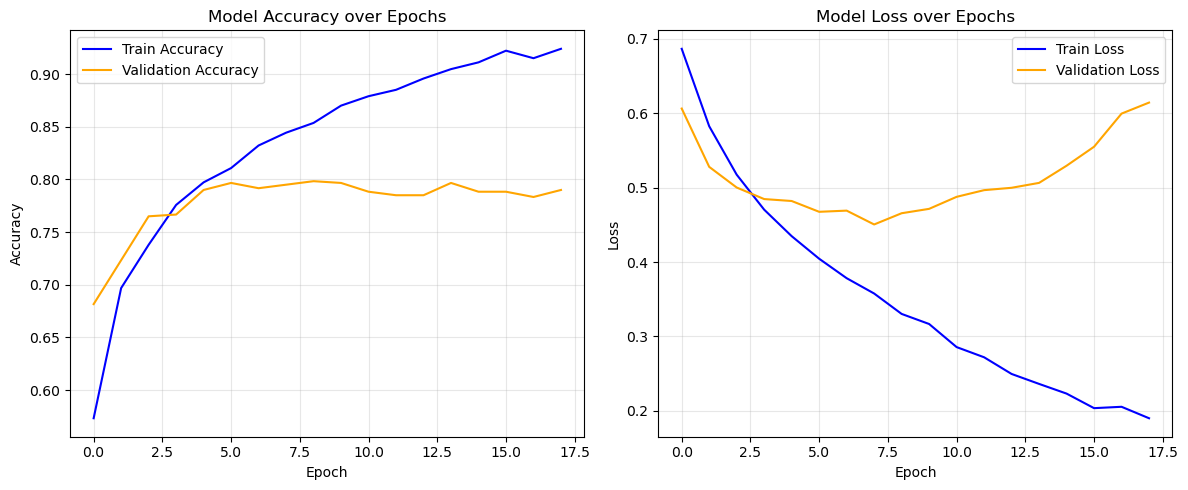

In [38]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix Display

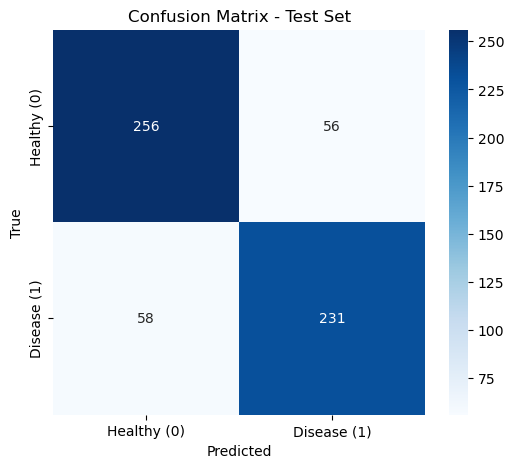


Classification Report (Test set):
              precision    recall  f1-score   support

     Healthy       0.82      0.82      0.82       312
     Disease       0.80      0.80      0.80       289

    accuracy                           0.81       601
   macro avg       0.81      0.81      0.81       601
weighted avg       0.81      0.81      0.81       601



In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Get predictions on test set
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()   # threshold 0.5

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Disease (1)'],
            yticklabels=['Healthy (0)', 'Disease (1)'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Also print classification report
from sklearn.metrics import classification_report
print("\nClassification Report (Test set):")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Disease']))

### dl_biomarkers_permutation_importance

Baseline validation accuracy: 0.7950
Computing permutation importance for 155 genes...


100%|██████████| 155/155 [02:03<00:00,  1.25it/s]



Top 20 model-predicted Biomarkers (permutation importance):
          gene  importance_mean  importance_std
0       SLC8A1         0.022333        0.005686
1        VCAM1         0.015500        0.002115
2         MEG3         0.014667        0.004876
3         TLR2         0.010667        0.002906
4      TACSTD2         0.009333        0.003742
5        CRIP1         0.009333        0.004842
6         SRGN         0.009000        0.002261
7       COL6A2         0.008667        0.003712
8          EGF         0.008333        0.007110
9         KLF2         0.008333        0.003496
10       TAGLN         0.008167        0.003371
11      CLEC4A         0.008000        0.005312
12       CCL18         0.008000        0.002449
13  HLA-DQB1/2         0.007833        0.004220
14     SPARCL1         0.007333        0.005228
15      COL9A2         0.006667        0.005676
16      SPOCK2         0.006667        0.003073
17    SERPINE1         0.006500        0.002930
18       GATA3         0.00

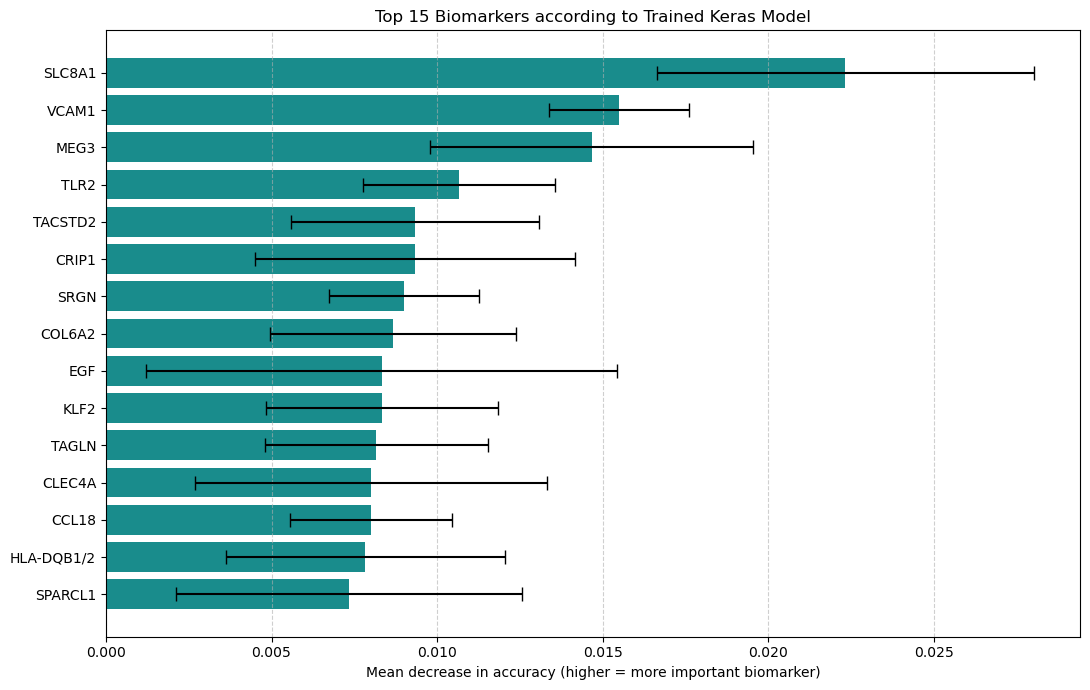

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm   # shows progress bar (nice to have)

# Number of times to shuffle each feature (higher = more stable, but slower)
n_repeats = 10          # 10–15 is usually enough; increase to 20 if you want more precision

# Get baseline performance on validation set
y_val_pred_prob = model.predict(X_val, verbose=0).flatten()
baseline_acc = np.mean((y_val_pred_prob > 0.5) == y_val)
print(f"Baseline validation accuracy: {baseline_acc:.4f}")

# Prepare importance array
n_features = X_val.shape[1]
importances = np.zeros((n_features, n_repeats))

print(f"Computing permutation importance for {n_features} genes...")

for col in tqdm(range(n_features)):
    X_shuffled = X_val.copy()
    
    for rep in range(n_repeats):
        # Shuffle only this column
        np.random.shuffle(X_shuffled[:, col])
        
        # Predict with shuffled data
        shuffled_pred_prob = model.predict(X_shuffled, verbose=0).flatten()
        shuffled_acc = np.mean((shuffled_pred_prob > 0.5) == y_val)
        
        # Importance = how much accuracy drops
        importances[col, rep] = baseline_acc - shuffled_acc

# Aggregate results
importance_df = pd.DataFrame({
    'gene': genes,                          # your gene/probe names from earlier
    'importance_mean': np.mean(importances, axis=1),
    'importance_std': np.std(importances, axis=1)
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

# Show top results
print("\nTop 20 model-predicted Biomarkers (permutation importance):")
print(importance_df.head(20))

# Save to file
importance_df.to_csv('dl_biomarkers_permutation_importance.csv', index=False)
print("Results saved to: dl_biomarkers_permutation_importance.csv")

# Visualize top 15
plt.figure(figsize=(11, 7))
plt.barh(
    importance_df['gene'].head(15),
    importance_df['importance_mean'].head(15),
    xerr=importance_df['importance_std'].head(15),
    capsize=5,
    color='teal',
    alpha=0.9
)
plt.gca().invert_yaxis()
plt.xlabel('Mean decrease in accuracy (higher = more important biomarker)')
plt.title('Top 15 Biomarkers according to DL Model')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Calibration Curve - Test Set

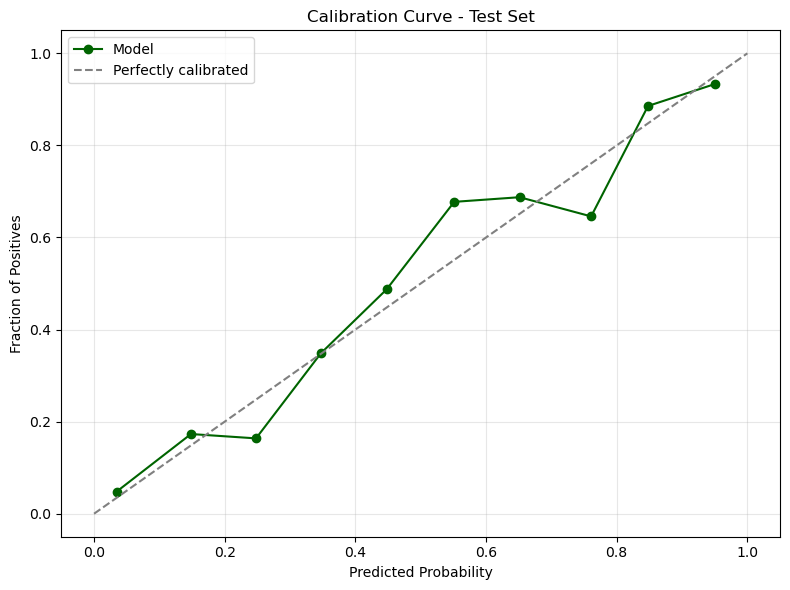

In [46]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model', color='darkgreen')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated', color='gray')
plt.xlabel('Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve - Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Print top biomarker

Plotting UMAP for top 6 biomarkers: ['SLC8A1', 'VCAM1', 'MEG3', 'TLR2', 'TACSTD2', 'CRIP1']


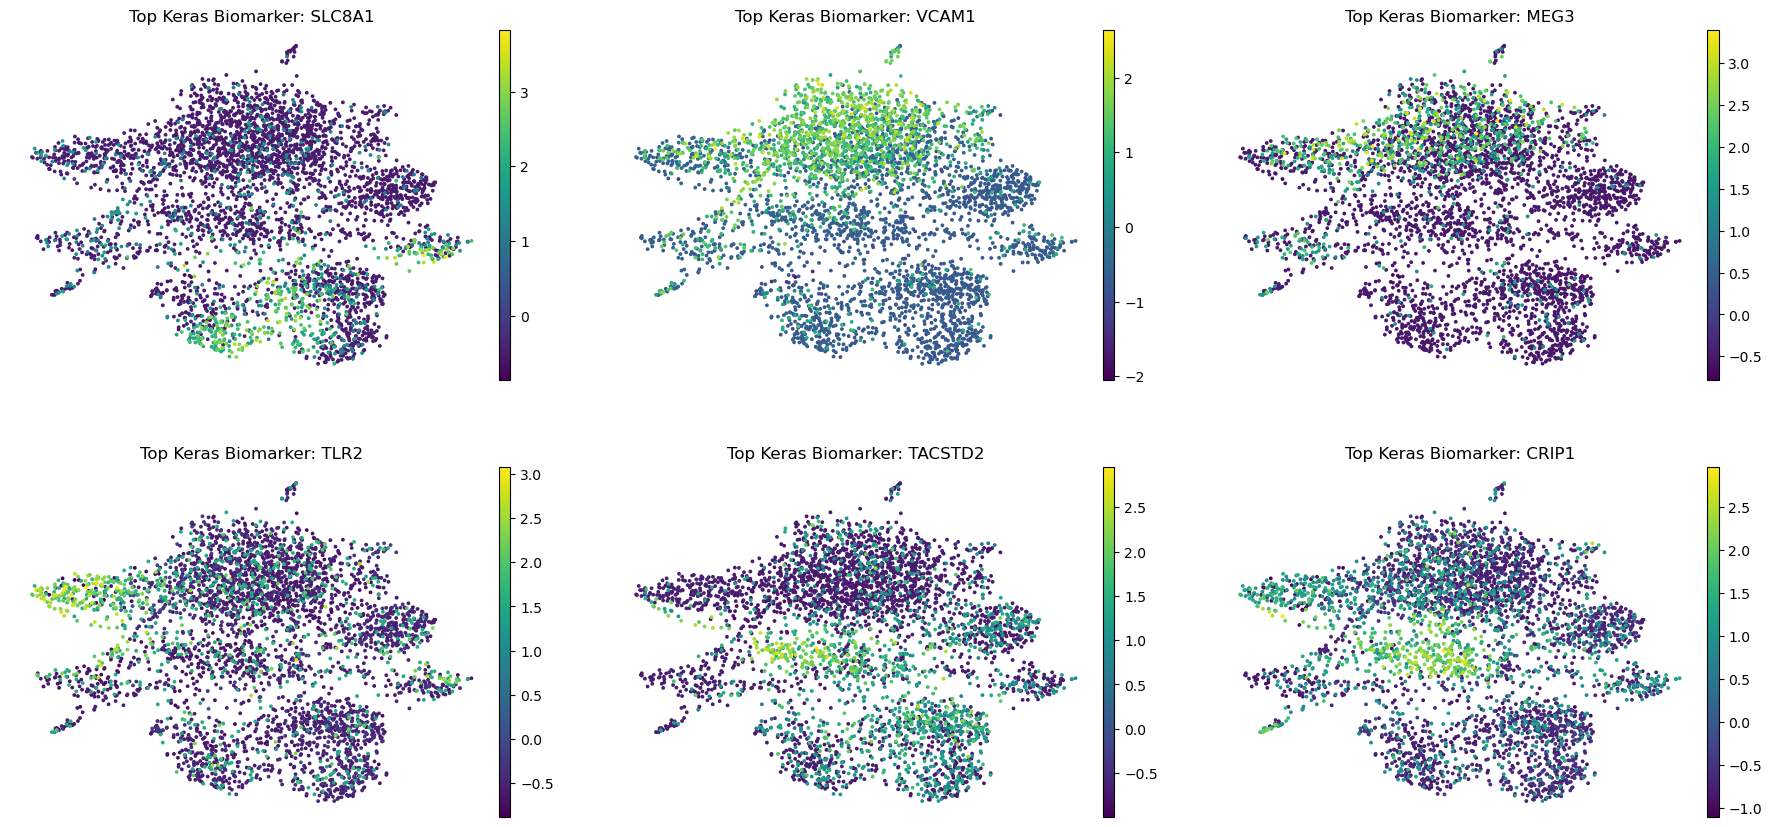

In [49]:
# Get top genes from your permutation importance CSV (or manually list top ones)
importance_df = pd.read_csv('keras_model_biomarkers_permutation_importance.csv')
top_genes_plot = importance_df['gene'].head(6).tolist()  # top 6 for nice grid

print("Plotting UMAP for top 6 biomarkers:", top_genes_plot)

sc.pl.umap(adata, 
           color=top_genes_plot, 
           ncols=3, 
           cmap='viridis', 
           frameon=False, 
           title=['Top Keras Biomarker: ' + g for g in top_genes_plot],
           show=True)

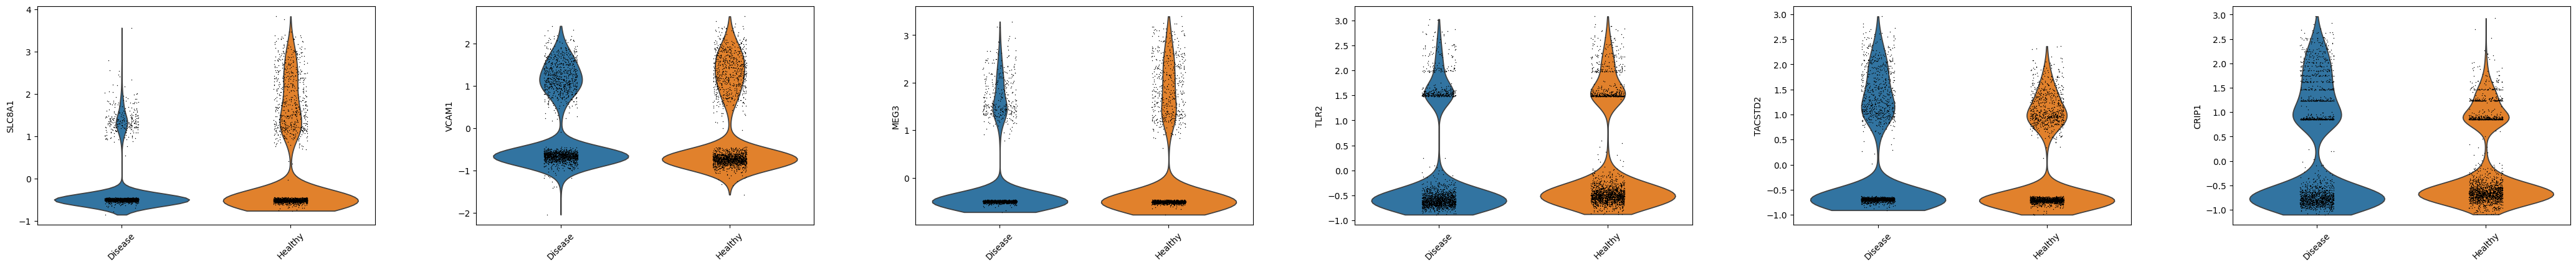

In [51]:
# Violin by 'type' (Healthy vs Disease)
sc.pl.violin(adata, 
             keys=top_genes_plot, 
             groupby='type', 
             rotation=45, 
             show=True)

### Heatmap of Top Biomarkers Expression (across cells, grouped by condition)

/home/nazmulhasan77/miniconda3/envs/rnaseq/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1400x1000 with 0 Axes>

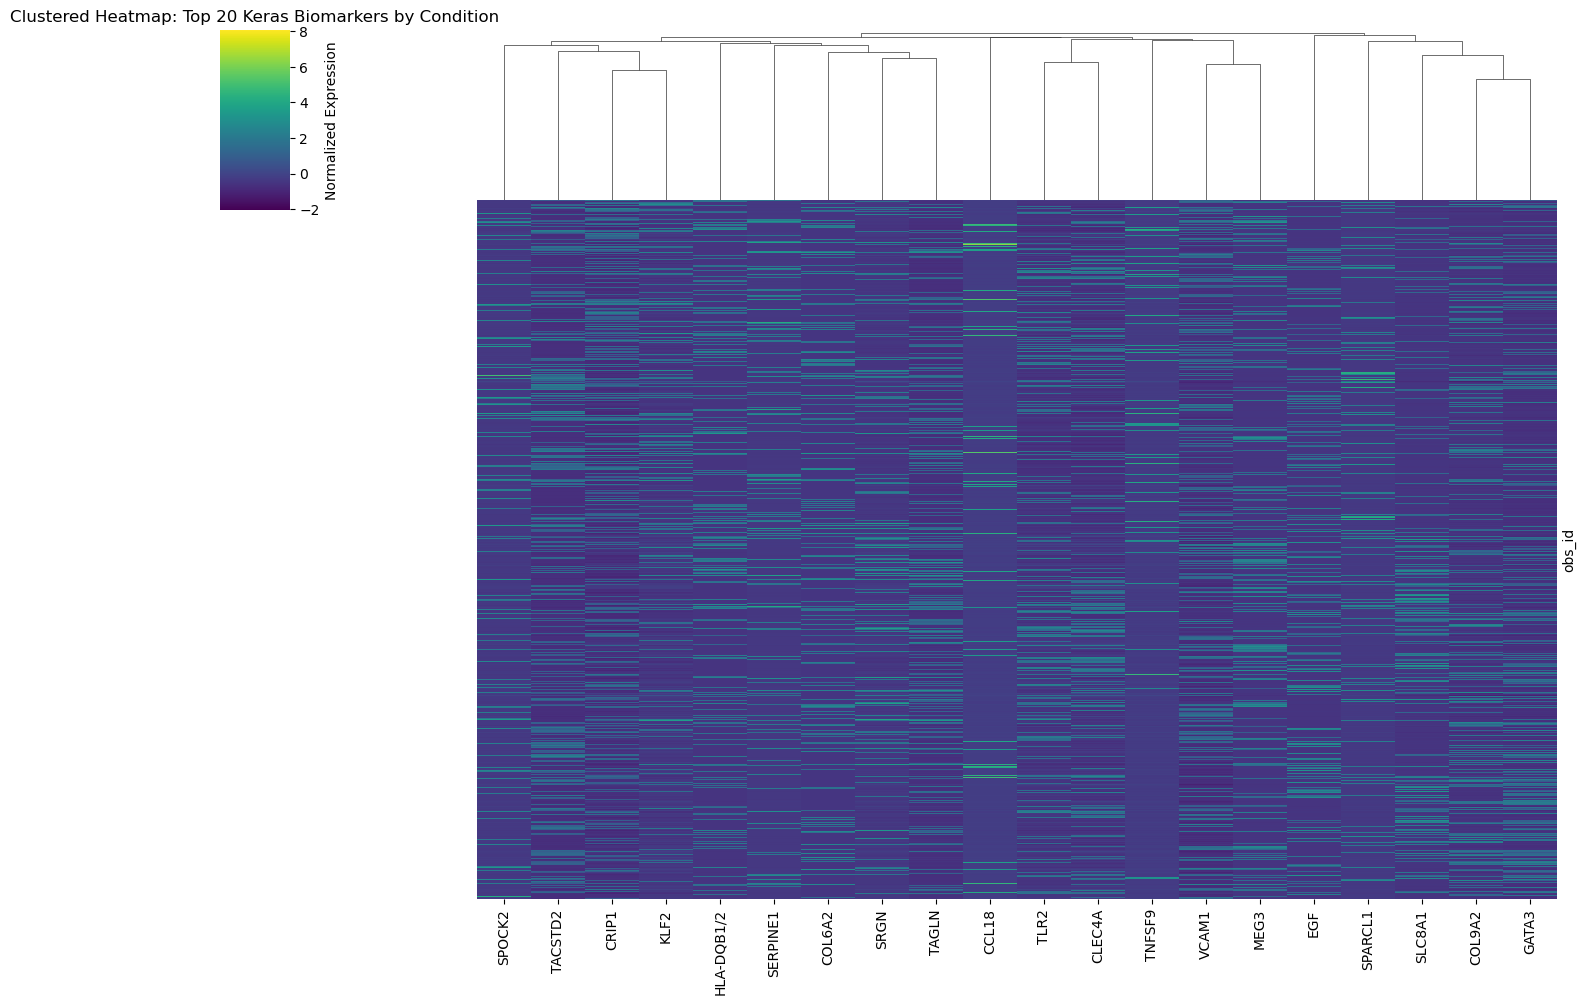

In [53]:
# Load or use your top genes
importance_df = pd.read_csv('keras_model_biomarkers_permutation_importance.csv')
top_genes_plot = importance_df['gene'].head(20).tolist()  # top 20 for heatmap

# Extract expression matrix for top genes (use normalized .X)
expr_matrix = pd.DataFrame(
    adata[:, top_genes_plot].X.toarray() if hasattr(adata.X, 'toarray') else adata[:, top_genes_plot].X,
    index=adata.obs_names,
    columns=top_genes_plot
)

# Add condition for grouping
expr_matrix['type'] = adata.obs['type'].values

# Sort cells by condition for better visualization
expr_matrix = expr_matrix.sort_values('type')

# Plot clustered heatmap
plt.figure(figsize=(14, 10))
sns.clustermap(
    expr_matrix.drop(columns='type'),
    cmap='viridis',
    row_cluster=False,           # keep condition order
    col_cluster=True,
    xticklabels=True,
    yticklabels=False,           # too many cells
    figsize=(14, 10),
    cbar_kws={'label': 'Normalized Expression'}
)

plt.title('Clustered Heatmap: Top 20 Keras Biomarkers by Condition')
plt.show()

### Pearson Correlation of Top Biomarkers (gene-gene relationships)

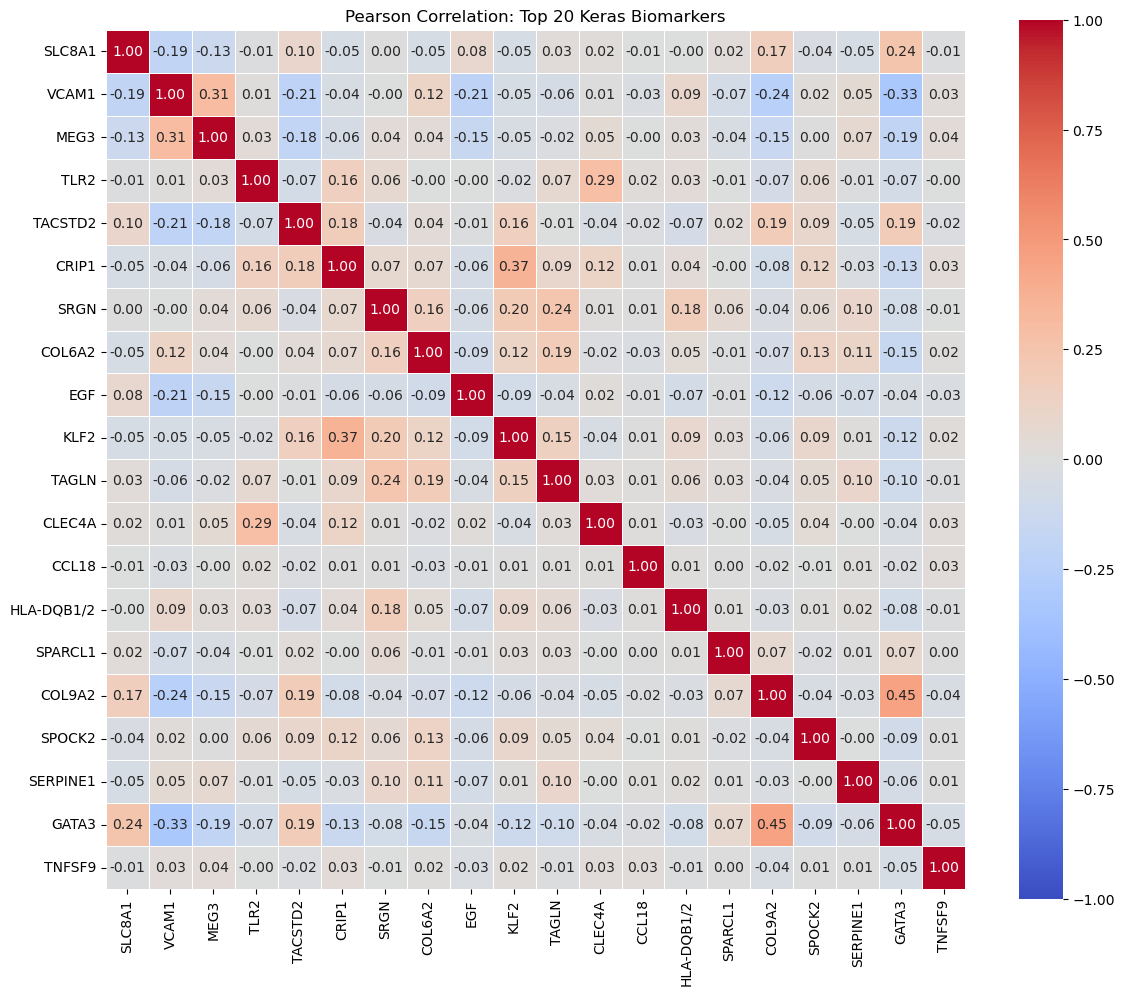

In [54]:
# Correlation matrix for top genes
corr_matrix = expr_matrix[top_genes_plot].corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Pearson Correlation: Top 20 Keras Biomarkers')
plt.tight_layout()
plt.show()

###  Bar Plot: Importance Comparison (DL vs Random Forest Model)

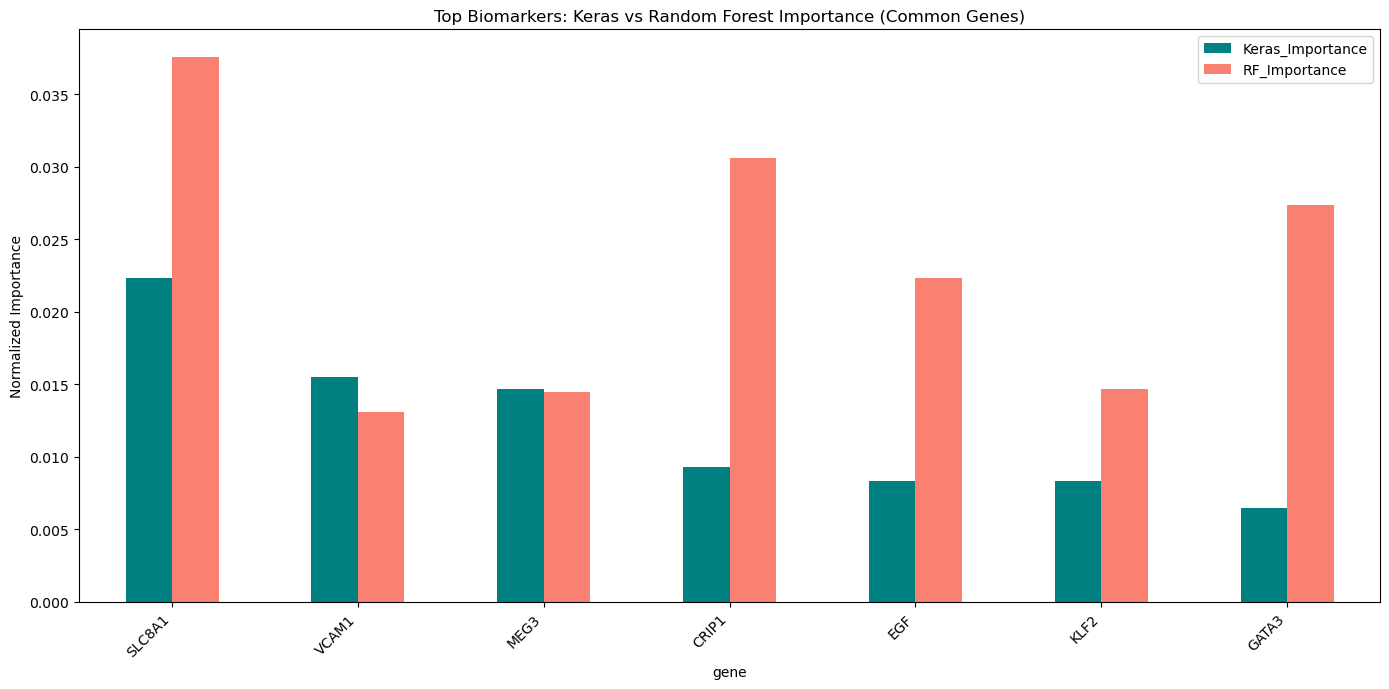

In [55]:
# Load both importance files
keras_imp = pd.read_csv('keras_model_biomarkers_permutation_importance.csv').head(20)
rf_imp = pd.read_csv('rf_biomarkers_disease_vs_healthy.csv').head(20)  # your RF file name

# Merge on gene (inner join for common genes)
merged = pd.merge(
    keras_imp[['gene', 'importance_mean']].rename(columns={'importance_mean': 'Keras_Importance'}),
    rf_imp[['gene', 'importance']].rename(columns={'importance': 'RF_Importance'}),
    on='gene',
    how='inner'
)

# Plot side-by-side
merged.plot(
    x='gene',
    y=['Keras_Importance', 'RF_Importance'],
    kind='bar',
    figsize=(14, 7),
    color=['teal', 'salmon']
)
plt.title('Top Biomarkers: Keras vs Random Forest Importance (Common Genes)')
plt.ylabel('Normalized Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Box Plots for Top 5 Biomarkers (by condition and cell type)

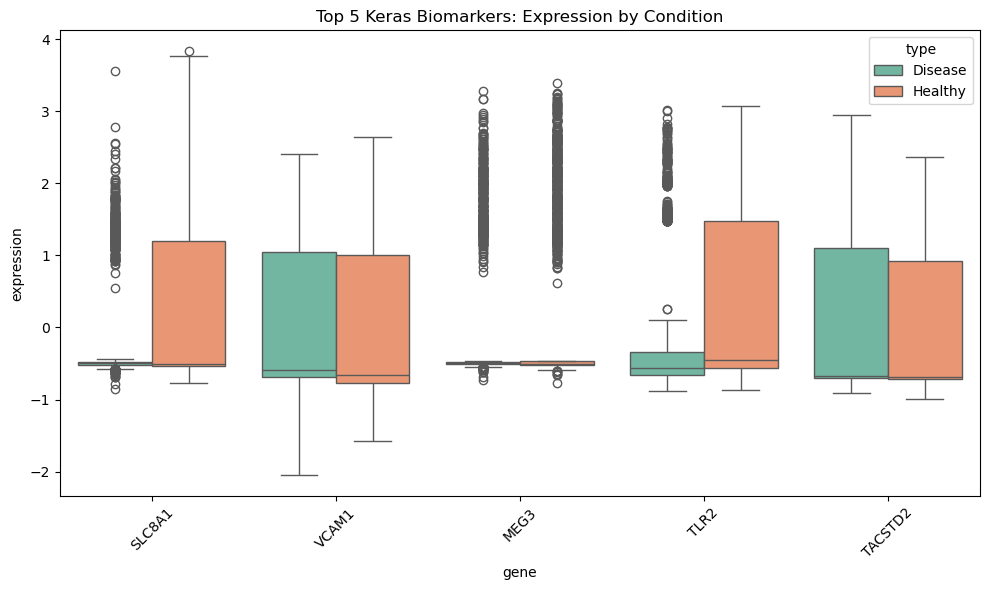

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Extract expression for top 5 genes
top5 = importance_df['gene'].head(5).tolist()

# Prepare long-format DataFrame
expr_df = pd.DataFrame(
    adata[:, top5].X.toarray() if hasattr(adata.X, 'toarray') else adata[:, top5].X,
    columns=top5
)
expr_df['type'] = adata.obs['type'].values

# Melt for seaborn
expr_long = expr_df.melt(id_vars='type', var_name='gene', value_name='expression')

# Boxplot by condition
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=expr_long,
    x='gene',
    y='expression',
    hue='type',
    palette='Set2'
)
plt.title('Top 5 Keras Biomarkers: Expression by Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
